## Example of Landlab 'landslide' component

This tutorial provides an example driver code that runs Landlab's 'landslide' component.
What a driver does is gathers input data, run the Landlab landslide component, and visualizes data and outputs.
Landlab is a Python-based landscape modeling environment and the landslide component is one of many components available for users to access and link together to build their own landscape model.
For more information about Landlab, see http://landlab.github.io/#/.

Input data is provide by the user and consists of elevation from a DEM to provide topographic traits such as slope, contributing area, and flow direction. The user also supplies soil characteristics derived from a soil survey,
land cover, or other sources, including transmissivity, cohesion, internal angle of friction, density, and thickness. 
Data for this example can be acquired from https://www.HydroShare.org under the resource "Thunder Creek Landlab Landslide Example".

Method calculates factor-of-safety stability index by using node specific parameters, creating distributions of these parameters, and calculating the index by sampling these distributions 'n' times. The index is calculated from the 'infinite slope stabilty factor-of-safety equation' in the format of Pack RT, Tarboton DG, and Goodwin CN (1998) 'The SINMAP approach to terrain stability mapping.'

Output includes figures of relative wetness, mean factor-of-safety, and probability of failure based on 
factor-of-safety calculations within a Monte Carlo simulation.

This version allows users to provide just a minimum and maximum recharge that us used in a uniform distribution rather than a spatially distributed recharge field. Thus, it is for testing and teaching purposes. It is design to run from the
same directory where the data files are located.

@author: R.Strauch and E.Istanbulluoglu - Univerity of Washington Created on Thu Aug 20 16:47:11 2015 Last edit July 20, 2016

Strauch, R., Istanbulluoglu, E., Nudurupati, S. S., Bandaragoda, C., Gasparini, N. M., and Tucker, G. E.: A hydroclimatological approach to predicting regional landslide probability using Landlab, Earth Surf. Dynam., 6, 49–75, https://doi.org/10.5194/esurf-6-49-2018, 2018. 


### To run example

To run this example, click in each shaded cell below and "shift + enter" to run each cell.
Alternatively, you can run groups of cells by clicking "Cell" on the menu above and selecting you run option.  This is also where you can clear outputs from previous runs.

If an error occurs, try "Restart" the kernel by clicking "Kernel" on the menu above.

### Import libraries and components

In [43]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
%matplotlib inline
import pylab

from landlab.plot.imshow import imshow_grid
#from landlab.plot.imshow import imshow_grid_at_node

# read ESRI
from landlab.io import esri_ascii

from landlab.components.flow_accum import flow_accumulation
from landlab.components.flow_accum import find_drainage_area_and_discharge

#from landlab.components.flow_accum import FlowAccumulator, SinkFiller
from landlab.components import FlowAccumulator, SinkFiller


from landlab.components.landslides import LandslideProbability

import time
st = time.time()

from osgeo import gdal

Min elevation of core nodes = 335.81348
Max elevation of core nodes = 2595.7073
max drainage area (km^2) = 307.0797000029297
verify_area (km^2) = 307.1086


/tmp/ipykernel_9575/3869982443.py:27: RuntimeWarning: divide by zero encountered in log10
  np.log10(da),


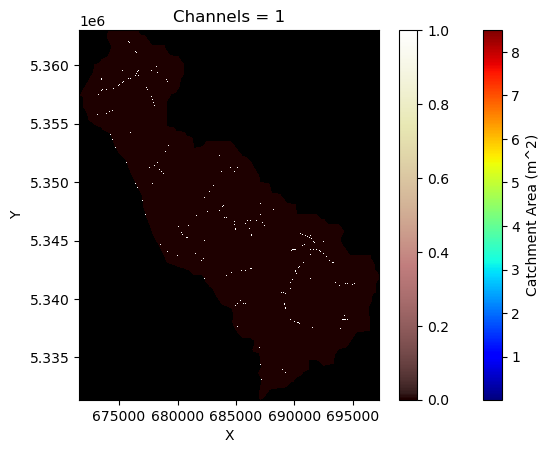

In [44]:
with open("/mnt/c/Users/amehedi/Downloads/ml_debris/pioneer/output/cut/topographic__elevation.asc") as fp:
    grid = esri_ascii.load(fp, name="topographic__elevation", at="node")

Z = grid.at_node["topographic__elevation"]
grid.set_nodata_nodes_to_closed(Z, -999999.0)

print("Min elevation of core nodes =", np.min(Z[grid.core_nodes]))
print("Max elevation of core nodes =", np.max(Z[grid.core_nodes]))

fa = FlowAccumulator(
    grid,
    surface="topographic__elevation",
    flow_director="FlowDirectorD8",
    runoff_rate=None,
    depression_finder="DepressionFinderAndRouter",
)

da, q = fa.accumulate_flow()

print("max drainage area (km^2) =", np.max(grid.at_node["drainage_area"]) / 1_000_000)

area = grid.number_of_core_nodes * grid.dx * grid.dy
print("verify_area (km^2) =", area / 1_000_000)

imshow_grid(
    grid,
    np.log10(da),
    at="node",
    plot_name="Log(Catchment Area)",
    var_name="Catchment Area",
    var_units="m^2",
    grid_units=("m", "m"),
    cmap="jet",
    limits=(0.01, 8.5),
)

channels = np.zeros(grid.number_of_nodes)
grid.add_field("Channels", channels, at="node", clobber=True)
grid.at_node["Channels"][da > 1_500_000] = 1

imshow_grid(grid, "Channels", at="node", plot_name="Channels = 1")

NOTE - Warnings about matplotlib and gFlex are OKAY and won't affect running the component.

In [ ]:
src = "/mnt/c/Users/amehedi/Downloads/topographic__elevation_excluded_inside_polygon.tif"
dst = "/mnt/c/Users/amehedi/Downloads/topographic__elevation_excluded_inside_polygon.asc"

ds = gdal.Open(src)
gdal.Translate(dst, ds, format="AAIGrid")
ds = None

In [ ]:
ds

### Load grid, fields, and constants

Reading a esri_ascii file from ArcGIS sets up the RasterModelGrid and assign elevation field to nodes. Nodes are the center point of grid cells or pixels that are 30 m by 30 m in this example.
The ascii (txt) files are located in the same directory where this notebook is run.
This might take 30 seconds.

In [46]:
with open("/mnt/c/Users/amehedi/Downloads/ml_debris/pioneer/output/cut/topographic__elevation.asc") as fp:
    grid = esri_ascii.load(fp, name="topographic__elevation", at="node")

Z = grid.at_node["topographic__elevation"]
# grid.set_watershed_boundary_condition(Z)

# grid.set_watershed_boundary_condition('topographic__elevation')

In [ ]:
import numpy as np
import pandas as pd

z = grid.at_node["topographic__elevation"]
valid = z[z != -999999.0]

pd.Series(valid).describe()

count    3.071097e+06
mean     1.629099e+03
std      4.724486e+02
min      3.358135e+02
25%      1.288313e+03
50%      1.739989e+03
75%      2.008914e+03
max      2.595707e+03
dtype: float64

In [22]:
grid.set_nodata_nodes_to_closed(Z, -999999.0)

all_nodes = np.arange(grid.number_of_nodes)
boundary_adj = grid.node_has_boundary_neighbor(all_nodes)

candidates = all_nodes[(Z != -999999.0) & boundary_adj]
outlet_id = candidates[np.argmin(Z[candidates])]

grid.set_watershed_boundary_condition_outlet_id(outlet_id, Z, -999999.0)

print("Outlet ID:", outlet_id)
print("Outlet elevation:", Z[outlet_id])

Outlet ID: 2737828
Outlet elevation: 335.81348


In [29]:
Z = grid.at_node["topographic__elevation"]
grid.set_nodata_nodes_to_closed(Z, -999999.0)

grid.set_closed_boundaries_at_grid_edges(True, True, True, True)

outlet_id = 8110528   # pick the actual outlet node you want
grid.status_at_node[outlet_id] = grid.BC_NODE_IS_FIXED_VALUE


In [ ]:
# with open("/mnt/c/Users/amehedi/Downloads/topographic__elevation_excluded_inside_polygon.asc") as fp:
#     grid = esri_ascii.load(fp, name="topographic__elevation", at="node")
# Z = grid.at_node["topographic__elevation"]


# #(grid,Z)=read_esri_ascii('PNW_watershed_dem.asc', name='topographic__elevation')  # read the DEM again  #NFN_21m.asc

# grid.set_watershed_boundary_condition('topographic__elevation') 

In [ ]:
cell_width = grid.dx
cell_width

Number of nodes= 8110530
Number of core nodes= 8099080
Area_of_core_nodes km2= 809.908


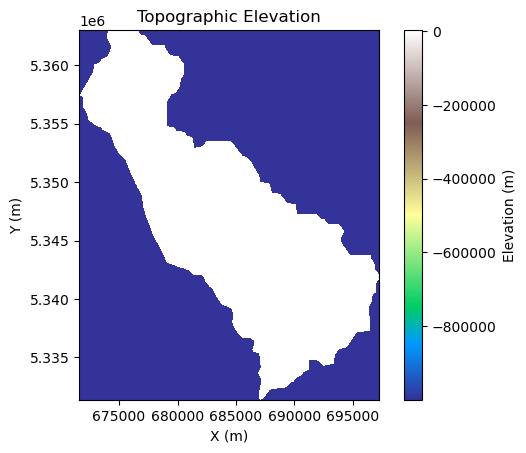

In [41]:
# Zmin=np.min(grid.at_node['topographic__elevation'][grid.core_nodes])
# Zmax=np.max(grid.at_node['topographic__elevation'][grid.core_nodes])

# print("Min elevation of core nodes=", Zmin) # print minimum elevation of core nodes
# print("Max elevation of core nodes=", Zmax) # print maximum elevation of core nodes

# imshow_grid(grid,'topographic__elevation', plot_name = 'Topographic Elevation', 
#             var_name = 'Elevation', var_units = 'm', grid_units = ('m','m'), 
#             cmap = 'jet', limits = (259, 853))
# plt.show()


print('Number of nodes=', grid.number_of_nodes)
print('Number of core nodes=', grid.number_of_core_nodes)

cell_width=grid.dx
cell_width

print('Area_of_core_nodes km2=', grid.number_of_core_nodes*grid.dx*grid.dy/1000000)

imshow_grid(grid,'topographic__elevation', plot_name = 'Topographic Elevation',
            var_name = 'Elevation', var_units = 'm', grid_units = ('m','m'),
            cmap = 'terrain')

plt.show()

Flow accumulations and drainage are calculation

In [31]:
# now fa is your object to run the FlowAccumulator method with the D8 flow directions and fill the depressions
fa = FlowAccumulator(grid,
                     surface='topographic__elevation',
                     flow_director='FlowDirectorD8',
                     runoff_rate=None)
# depression_finder='DepressionFinderAndRouter')

In [35]:
(da, q) = fa.accumulate_flow()

In [36]:
print('max drainge area (km^2)=', np.max(grid.at_node['drainage_area'][grid.nodes])/1000000)

max drainge area (km^2)= 67.39010000585938


**Map contributing area of each cell**

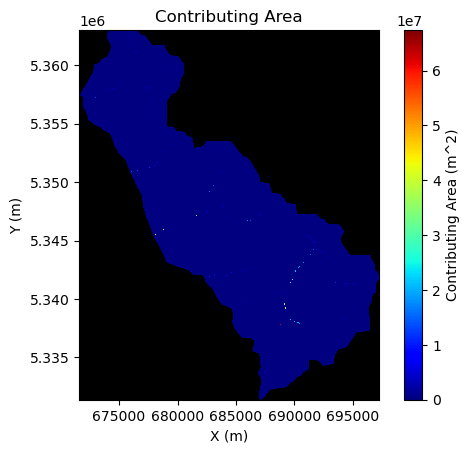

In [37]:
imshow_grid(grid,'drainage_area', plot_name = 'Contributing Area', 
            var_name = 'Contributing Area', var_units = 'm^2', grid_units = ('m','m'), 
            cmap = 'jet')

/tmp/ipykernel_9575/2304773029.py:1: RuntimeWarning: divide by zero encountered in log10
  imshow_grid(grid, np.log10(da), plot_name = 'Log(Catchment Area)',


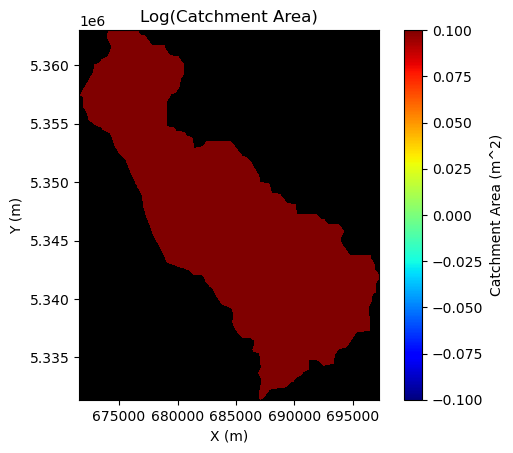

In [48]:
imshow_grid(grid, np.log10(da), plot_name = 'Log(Catchment Area)', 
            var_name = 'Catchment Area', var_units = 'm^2', grid_units = ('m','m'), 
            cmap = 'jet')

Slope - Area plot of the watershed

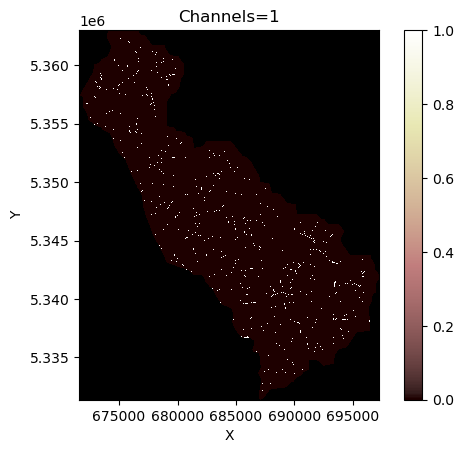

In [39]:
Channels=np.zeros(grid.number_of_nodes)

_=grid.add_field('Channels',Channels, at='node', clobber=True) # example for new way of creating the field. 

grid.at_node['Channels'][np.where(da>150000)] = 1   # cont

imshow_grid(grid, 'Channels', plot_name = 'Channels=1')

**Prepare  Input for Landslide probability component**

Check what other fields you need for the landslide probability component. Fields are data values that are assigned to each node, providing spatial variability to landscape. You check the input parameter names and input fields by commenting out the lines below.

In [13]:
#sorted(LandslideProbability.input_var_names)

In [14]:
#LandslideProbability?

Check for Variable Units

In [15]:
print('soil mode total cohesion :', LandslideProbability.var_units('soil__mode_total_cohesion'))
print('saturated hydraulic conductivity :', LandslideProbability.var_units('soil__saturated_hydraulic_conductivity'))
print('soil transmissivity :', LandslideProbability.var_units('soil__transmissivity'))
print('soil internal friction angle :', LandslideProbability.var_units('soil__internal_friction_angle'))

soil mode total cohesion : Pa or kg/m-s2
saturated hydraulic conductivity : m/day
soil transmissivity : m2/day
soil internal friction angle : degrees


*Specific catchment area* is calculate here and assigned as a field using the name searched by the component

In [16]:
cell_width=grid.dx

ca=grid.at_node['drainage_area']/cell_width  # now calculate SCA

_=grid.add_field('node', 'topographic__specific_contributing_area', ca, clobber=True)

/tmp/ipykernel_9575/497295447.py:5: FutureWarning: Calling `add_field` with the field location as the first argument is deprecated and will be removed in future versions. Instead, please use the `at` keyword to specify the location: add_field(arg0, arg1, at='node').
  _=grid.add_field('node', 'topographic__specific_contributing_area', ca, clobber=True)


*Topographic slope:* we will use the steepest slope calculated as part of flow routing as input to landslide probability using the name "topographic__slope" because landslide probability requires this name.

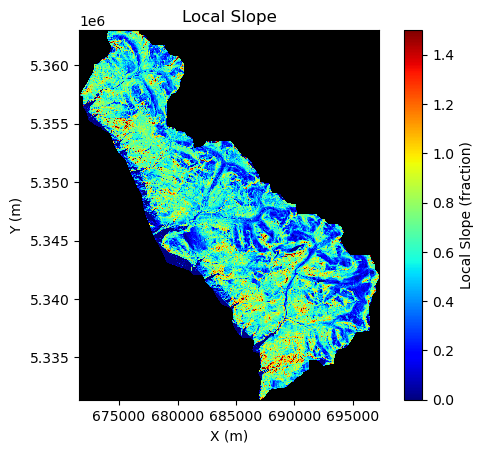

In [45]:
imshow_grid(grid,'topographic__steepest_slope', plot_name = 'Local Slope', 
            var_name = 'Local Slope', var_units = 'fraction', grid_units = ('m','m'), 
            cmap = 'jet', limits = (0, 1.5))

In [18]:
TS=grid.at_node['topographic__steepest_slope']

_=grid.add_field('node', 'topographic__slope', TS, clobber=True)

/tmp/ipykernel_9575/2807283213.py:3: FutureWarning: Calling `add_field` with the field location as the first argument is deprecated and will be removed in future versions. Instead, please use the `at` keyword to specify the location: add_field(arg0, arg1, at='node').
  _=grid.add_field('node', 'topographic__slope', TS, clobber=True)


**Assign model parameters as fields**

In [19]:
# these three parameters are used to paramaterize a triangler distribution used to quantify uncertainty in root cohesion over space and time

C_min=3     # min cohesion kPa-- this includes both soil and vegetation cohesion
C_max=14    # max cohesion kPa-- this includes both soil and vegetation cohesion
Cmode=7    # mode of cohesion kPA

soil_density=2000 # kg/m3

Phi=30      # internal friction angle in degrees
Ks=5        # Ksat (m/day)

hs_min=1.5  #soil thickness min
hs_max=1.5  #soil thickness max

grid.add_field('soil__minimum_total_cohesion', C_min*1000*np.ones(grid.number_of_nodes), at='node', clobber=True)    ## I changed this one.. 
grid.add_field('node', 'soil__maximum_total_cohesion', C_max*1000*np.ones(grid.number_of_nodes), clobber=True)
grid.add_field('node', 'soil__mode_total_cohesion', Cmode*1000*np.ones(grid.number_of_nodes), clobber=True)
grid.add_field('node', 'soil__density', soil_density*np.ones(grid.number_of_nodes), clobber=True)
grid.add_field('node', 'soil__internal_friction_angle', Phi*np.ones(grid.number_of_nodes), clobber=True)
grid.add_field('node', 'soil__saturated_hydraulic_conductivity', Ks*np.ones(grid.number_of_nodes), clobber=True)

/tmp/ipykernel_9575/481701256.py:16: FutureWarning: Calling `add_field` with the field location as the first argument is deprecated and will be removed in future versions. Instead, please use the `at` keyword to specify the location: add_field(arg0, arg1, at='node').
  grid.add_field('node', 'soil__maximum_total_cohesion', C_max*1000*np.ones(grid.number_of_nodes), clobber=True)
/tmp/ipykernel_9575/481701256.py:17: FutureWarning: Calling `add_field` with the field location as the first argument is deprecated and will be removed in future versions. Instead, please use the `at` keyword to specify the location: add_field(arg0, arg1, at='node').
  grid.add_field('node', 'soil__mode_total_cohesion', Cmode*1000*np.ones(grid.number_of_nodes), clobber=True)
/tmp/ipykernel_9575/481701256.py:18: FutureWarning: Calling `add_field` with the field location as the first argument is deprecated and will be removed in future versions. Instead, please use the `at` keyword to specify the location: add_fie

array([5., 5., 5., ..., 5., 5., 5.], shape=(8110530,))

**Soil Thickness**

Soil thickness is low on hillslopes and deeper in the valleys. Here we use a simple model to relate soil thickness to elevation to create a soil thicnkness map 

In [20]:
hs=hs_max-((Z-Zmin)/(Zmax-Zmin))*(hs_max-hs_min)
_=grid.add_field('node', 'soil__thickness', hs*np.ones(grid.number_of_nodes), clobber=True)

NameError: name 'Zmin' is not defined

**Transmissivity:** this is depth integrated saturated hydraulic conductivity, Ks.  This will come from the SSURGU data

In [ ]:
To=Ks*hs
_=grid.add_field('node', 'soil__transmissivity', To*np.ones(grid.number_of_nodes), clobber=True)

Recharge input: This is a conceptual range of input for the statical distribution of recharge input.

In [ ]:
groundwater__recharge_mean=20; #
groundwater__recharge_standard_deviation=5; #

**Run landslide component to calculate probability of failure**

In [ ]:
number_of_iterations = 500

In [ ]:
LS_prob=LandslideProbability(grid,
                         number_of_iterations=number_of_iterations,
                         groundwater__recharge_distribution='lognormal',
                         groundwater__recharge_mean=groundwater__recharge_mean,
                         groundwater__recharge_standard_deviation=groundwater__recharge_standard_deviation)

In [ ]:
LS_prob.calculate_landslide_probability()

### Make plots and figures

Plot relative wetness with countours

In [ ]:
plt.figure('Mean Relative Wetness')
imshow_grid_at_node(grid, 'soil__mean_relative_wetness', cmap='YlGnBu',
                 grid_units=('coordinates', 'coordinates'),
                 shrink=0.75, var_name='Relative Wetness',
                 var_units='no units')
# this plots the contour lines
#cs = pylab.contour(elev, extent=[0,42500, 0,32500], hold='on', colors='gray')
#pylab.clabel(cs, inline=True, fmt='%1i', fontsize=10, manual=manual_locals)
#imshow_grid_at_node(grid, overlay_watershed, color_for_closed='None',
#                 allow_colorbar=False, cmap='spring')

Plot probability of failure

In [ ]:
plt.figure('Probability of Failure')
imshow_grid_at_node(grid, 'landslide__probability_of_failure', cmap='OrRd',
                 grid_units=('coordinates', 'coordinates'), shrink=1,
                 var_name='Probability of Failure',limits = (0, 1))


This map shows the probability of failure based on then number of simulations where the factor-of-safety was <= 1.0 out all the simulations. The probability tends to be higer in the upper portions of the watershed where cohesion is less and soils are shallower, quickly saturating.

In [ ]:
prob = grid.at_node['landslide__probability_of_failure']
plt.style.use('ggplot')
plt.hist(prob, bins=[0, 0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9])
plt.xlabel('Probability of Failure')
plt.ylabel ('Number of Cells')
plt.title('Landslide Probability of Failure')
plt.ylim = 10000
plt.show()

Landslide probability plotted with respect to local slope

In [ ]:
core_mask = np.where(grid.core_nodes)
boundary_neighbor_mask = grid.node_has_boundary_neighbor(grid.nodes.flatten())
core_interior = np.all([core_mask, np.invert(boundary_neighbor_mask)], 0)


plt.loglog(
    grid.at_node['topographic__steepest_slope'][core_interior],
    grid.at_node['landslide__probability_of_failure'][core_interior],
    'k.'
)

plt.xlabel('local slope')
plt.ylabel('Probability of landsliding')
_ = plt.title('Slope-Area Plot')

plt.xlim(0.2, 1.2)

plt.show()